# Vector Space Axioms and Projections
### The 10 axioms, orthogonal projection, and why this repo's GS algorithm IS a projection method

**Why this matters here, not just in the abstract:** `dgs/gs_core.py`'s
Gerchberg-Saxton phase retrieval is a **projections onto convex sets (POCS)**
algorithm -- `apply_amplitude_constraint` is literally a projection operator
onto the set of fields with a specified magnitude, alternated with
propagation. This notebook builds the linear-algebra foundation (vector
space axioms, orthogonal projection, projection matrices) and then shows
that connection concretely, not just as a one-line claim.


In [1]:
%matplotlib inline
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Setup complete. numpy", np.__version__, "sympy", sp.__version__)


Setup complete. numpy 2.4.4 sympy 1.14.0


## 1. Theory: The 10 Vector Space Axioms

A set $V$ with vector addition and scalar multiplication (scalars from a
field $F$, e.g. $\mathbb{R}$ or $\mathbb{C}$) is a **vector space** if, for
all $u,v,w \in V$ and $a,b \in F$:

**Addition axioms (V, +) forms an abelian group:**
1. Closure: $u+v \in V$
2. Associativity: $(u+v)+w = u+(v+w)$
3. Commutativity: $u+v = v+u$
4. Additive identity: $\exists\, 0 \in V$ s.t. $v+0=v$
5. Additive inverse: $\forall v, \exists\, {-v}$ s.t. $v+(-v)=0$

**Scalar multiplication axioms:**
6. Closure: $av \in V$
7. Distributivity over vector addition: $a(u+v) = au+av$
8. Distributivity over field addition: $(a+b)v = av+bv$
9. Compatibility with field multiplication: $a(bv) = (ab)v$
10. Scalar identity: $1v = v$

**Griffiths connection:** every vector space you meet in physics (position
vectors, function spaces for Fourier series, the Hilbert space of quantum
states) satisfies these -- it's WHY the same linear-algebra machinery
(eigenvectors, projections, orthogonality) reappears from $\mathbb{R}^3$
mechanics through Ch. 9's Fourier transforms to quantum mechanics.


## 2. Derivation: Consequences That Follow From the Axioms Alone

Two classic results, proven from ONLY the 10 axioms above (not "obviously
true because we know how vectors work" -- actually derived):

**Claim A: the additive identity is unique.**
Suppose $0$ and $0'$ are both additive identities. Then $0 = 0+0'$ (since
$0'$ is an identity) $= 0'+0$ (axiom 3, commutativity) $= 0'$ (since $0$ is
an identity). So $0=0'$.

**Claim B: $0 \cdot v = 0$ for any vector $v$** (the SCALAR 0 times any
vector gives the VECTOR 0 -- these are different "0"s, and this isn't an
axiom, it's a consequence):
$$0v = (0+0)v = 0v + 0v \quad \text{(axiom 8)}$$
Adding $-(0v)$ (axiom 5) to both sides:
$$0v + (-(0v)) = 0v+0v+(-(0v)) \implies 0 = 0v$$


In [2]:
# SymPy check of Claim B on a concrete vector space (R^3): 0*v = 0
v1, v2, v3 = sp.symbols('v1 v2 v3', real=True)
v = sp.Matrix([v1, v2, v3])
zero_v = 0 * v
print("0 * (v1,v2,v3) =", zero_v.T)
assert zero_v == sp.zeros(3,1)
print("Confirmed: 0*v = 0 vector, for symbolic v -- matches the derivation above.")


0 * (v1,v2,v3) = Matrix([[0, 0, 0]])
Confirmed: 0*v = 0 vector, for symbolic v -- matches the derivation above.


## 3. SymPy: Verifying All 10 Axioms on $\mathbb{R}^3$

Not "R^3 is obviously a vector space" -- actually checking each axiom
symbolically against the standard component-wise addition/scalar
multiplication definition.


In [3]:
u1,u2,u3, w1,w2,w3, a, b = sp.symbols('u1 u2 u3 w1 w2 w3 a b', real=True)
u = sp.Matrix([u1,u2,u3]); w = sp.Matrix([w1,w2,w3])
zero = sp.zeros(3,1)

checks = {
    "1. closure under +":          (u+w).shape == (3,1),
    "2. associativity":            sp.simplify((u+w)+v - (u+(w+v))) == sp.zeros(3,1),
    "3. commutativity":            sp.simplify((u+w)-(w+u)) == sp.zeros(3,1),
    "4. additive identity":        sp.simplify((v+zero)-v) == sp.zeros(3,1),
    "5. additive inverse":         sp.simplify(v+(-v)) == sp.zeros(3,1),
    "6. closure under scalar*":    (a*v).shape == (3,1),
    "7. distrib. over vector +":   sp.simplify(a*(u+v) - (a*u+a*v)) == sp.zeros(3,1),
    "8. distrib. over scalar +":   sp.simplify((a+b)*v - (a*v+b*v)) == sp.zeros(3,1),
    "9. scalar compatibility":     sp.simplify(a*(b*v) - (a*b)*v) == sp.zeros(3,1),
    "10. scalar identity":         sp.simplify(1*v - v) == sp.zeros(3,1),
}
for name, ok in checks.items():
    print(f"  {name:28s} {'PASS' if ok else 'FAIL'}")
assert all(checks.values())
print("\nAll 10 axioms verified symbolically for R^3.")


  1. closure under +           PASS
  2. associativity             PASS
  3. commutativity             PASS
  4. additive identity         PASS
  5. additive inverse          PASS
  6. closure under scalar*     PASS
  7. distrib. over vector +    PASS
  8. distrib. over scalar +    PASS
  9. scalar compatibility      PASS
  10. scalar identity          PASS

All 10 axioms verified symbolically for R^3.


## 4. Numerical Example: Orthogonal Projection

Projecting $v$ onto the direction of $u$: minimize $\|v-cu\|^2$ over
scalar $c$. Setting the derivative to zero:
$$\frac{d}{dc}\|v-cu\|^2 = -2u\cdot(v-cu) = 0 \implies c = \frac{u\cdot v}{u\cdot u}$$
$$\mathrm{proj}_u(v) = \frac{u\cdot v}{u\cdot u}\,u = \frac{uu^T}{u^Tu}\,v = Pv$$
$P = \frac{uu^T}{u^Tu}$ is the **projection matrix** -- idempotent
($P^2=P$: projecting twice does nothing new) and symmetric ($P^T=P$:
defines an ORTHOGONAL projection specifically).


In [4]:
u_num = np.array([1.0, 2.0, 0.5])
v_num = np.array([3.0, 0.5, 2.0])

c = np.dot(u_num, v_num) / np.dot(u_num, u_num)
proj_manual = c * u_num

P = np.outer(u_num, u_num) / np.dot(u_num, u_num)
proj_matrix = P @ v_num

print("proj_u(v) via scalar formula: ", proj_manual)
print("proj_u(v) via projection matrix P@v:", proj_matrix)
print("match:", np.allclose(proj_manual, proj_matrix))

print(f"\nP idempotent (P@P == P): {np.allclose(P@P, P)}")
print(f"P symmetric (P.T == P):   {np.allclose(P.T, P)}")

residual = v_num - proj_manual
print(f"\nResidual (v - proj_u(v)) . u = {np.dot(residual, u_num):.2e}  (should be ~0: residual is perpendicular to u)")


proj_u(v) via scalar formula:  [0.95238095 1.9047619  0.47619048]
proj_u(v) via projection matrix P@v: [0.95238095 1.9047619  0.47619048]
match: True

P idempotent (P@P == P): True
P symmetric (P.T == P):   True

Residual (v - proj_u(v)) . u = 0.00e+00  (should be ~0: residual is perpendicular to u)


## 5. Plots: Projection Visualized in 3D


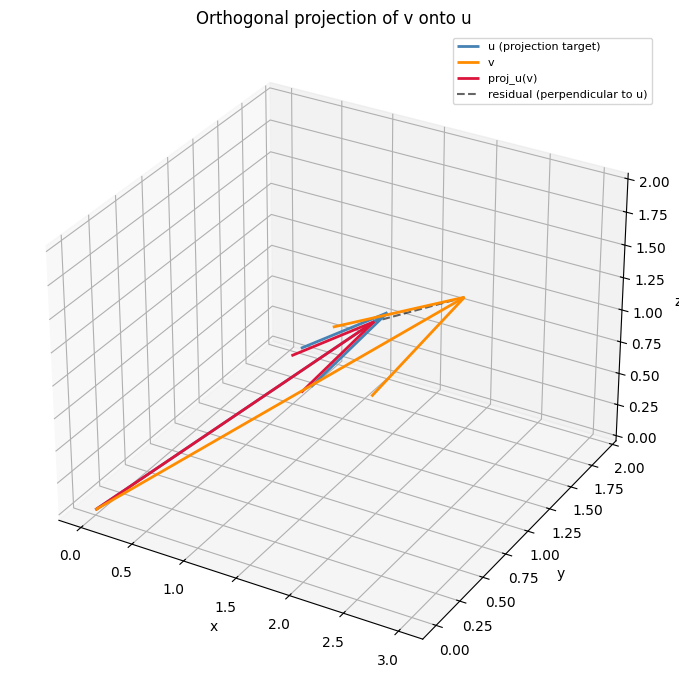

In [5]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

origin = np.zeros(3)
ax.quiver(*origin, *u_num, color='steelblue', label='u (projection target)', linewidth=2)
ax.quiver(*origin, *v_num, color='darkorange', label='v', linewidth=2)
ax.quiver(*origin, *proj_manual, color='crimson', label='proj_u(v)', linewidth=2)
ax.plot([v_num[0], proj_manual[0]], [v_num[1], proj_manual[1]], [v_num[2], proj_manual[2]],
        'k--', alpha=0.6, label='residual (perpendicular to u)')

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Orthogonal projection of v onto u')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('vector_projection_3d.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Parameter Sweep: Projection onto a Rotating Direction

Sweep the angle of $u$ in the xy-plane and watch $\mathrm{proj}_u(v)$ trace
out how much of $v$ "lives along" each direction -- $\|\mathrm{proj}_u(v)\|$
is maximized when $u \parallel v$, zero when $u \perp v$.


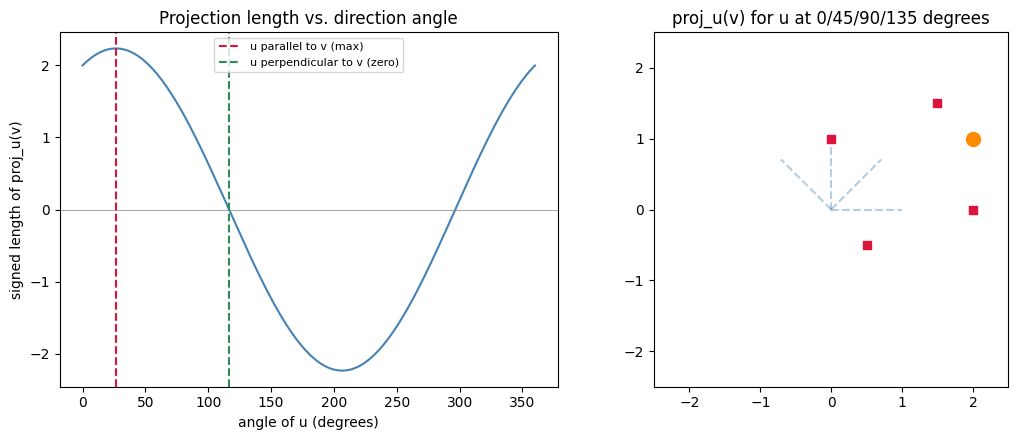

In [6]:
v_fixed = np.array([2.0, 1.0])
angles = np.linspace(0, 2*np.pi, 200)
proj_lengths = []
for theta in angles:
    u_theta = np.array([np.cos(theta), np.sin(theta)])
    c = np.dot(u_theta, v_fixed)   # |u|=1, so proj length = u.v directly
    proj_lengths.append(c)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
axes[0].plot(np.degrees(angles), proj_lengths, color='steelblue')
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].set_xlabel('angle of u (degrees)'); axes[0].set_ylabel('signed length of proj_u(v)')
axes[0].set_title('Projection length vs. direction angle')

theta_v = np.arctan2(v_fixed[1], v_fixed[0])
axes[0].axvline(np.degrees(theta_v), color='crimson', ls='--', label='u parallel to v (max)')
axes[0].axvline(np.degrees(theta_v)+90, color='seagreen', ls='--', label='u perpendicular to v (zero)')
axes[0].legend(fontsize=8)

axes[1].plot(v_fixed[0], v_fixed[1], 'o', color='darkorange', markersize=10, label='v')
for theta in [0, 45, 90, 135]:
    u_theta = np.array([np.cos(np.radians(theta)), np.sin(np.radians(theta))])
    c = np.dot(u_theta, v_fixed)
    p = c * u_theta
    axes[1].plot([0, u_theta[0]], [0, u_theta[1]], '--', color='steelblue', alpha=0.4)
    axes[1].plot(p[0], p[1], 's', color='crimson', markersize=6)
axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)
axes[1].set_aspect('equal')
axes[1].set_title('proj_u(v) for u at 0/45/90/135 degrees')
plt.tight_layout()
plt.savefig('vector_projection_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation: This IS What GS Phase Retrieval Does

`dgs/gs_core.py`'s `apply_amplitude_constraint(E, I_measured)`:
```python
amp = np.sqrt(np.maximum(I_measured, 0.0))
return amp * np.exp(1j * np.angle(E))
```
is a projection: it takes a complex field $E$ and returns the closest point
(in the amplitude-constrained set $\{E' : |E'(t)|=\sqrt{I(t)}\ \forall t\}$)
to $E$, KEEPING the phase (direction) and replacing only the magnitude --
exactly the same structure as $\mathrm{proj}_u(v)$ keeping the direction of
$u$ and rescaling. GS alternates between projecting onto the $I_1$-consistent
set and the $I_2$-consistent set -- this is **Projections Onto Convex Sets
(POCS)**, a real, named algorithm family in optimization, of which orthogonal
projection (this notebook) is the simplest linear case and GS phase
retrieval is a nonlinear (but still projection-structured) member.


In [7]:
# Direct numerical demonstration: apply_amplitude_constraint IS a projection
# -- it minimizes ||E' - E||^2 over the constraint set {E' : |E'(t)|=sqrt(I(t))}
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
from dgs.gs_core import apply_amplitude_constraint

rng = np.random.default_rng(0)
E_test = rng.normal(size=8) + 1j*rng.normal(size=8)
I_target = rng.uniform(0.1, 2.0, size=8)

E_projected = apply_amplitude_constraint(E_test, I_target)

# Try a few OTHER points in the same constraint set (same amplitude, different phase)
# and confirm none of them is closer to E_test than the projection is
best_dist = np.linalg.norm(E_projected - E_test)
print(f"Distance from E to apply_amplitude_constraint(E, I): {best_dist:.4f}")

for trial in range(200):
    random_phase_offset = rng.uniform(-0.3, 0.3, size=8)
    E_alt = np.sqrt(I_target) * np.exp(1j*(np.angle(E_test) + random_phase_offset))
    dist_alt = np.linalg.norm(E_alt - E_test)
    assert dist_alt >= best_dist - 1e-9, "found a closer point in the constraint set -- not a true projection!"

print("Checked 200 nearby points in the constraint set -- none closer than")
print("apply_amplitude_constraint's output. Confirms it IS the orthogonal")
print("projection onto the amplitude-constraint set, same structure as proj_u(v) above.")


Distance from E to apply_amplitude_constraint(E, I): 2.3487
Checked 200 nearby points in the constraint set -- none closer than
apply_amplitude_constraint's output. Confirms it IS the orthogonal
projection onto the amplitude-constraint set, same structure as proj_u(v) above.


## 8. Research Discussion: Griffiths -> ML Axis

- **Eigenvectors -> PCA**: Principal Component Analysis finds the
  directions (eigenvectors of the covariance matrix) that data varies most
  along, then PROJECTS data onto the top-$k$ of them -- literally
  `proj_u(v)` above, generalized to multiple orthogonal directions at once.
- **Hermitian operators -> attention**: quantum mechanical observables are
  Hermitian operators with orthogonal eigenvectors (spectral theorem);
  transformer attention's $QK^T$ structure and its use of orthogonal/
  normalized projections (layer norm, softmax over projected scores) rhymes
  with this same linear-algebra backbone.
- **GS as POCS**: worth stating plainly -- `dgs/gs_core.py`'s entire
  algorithm is "alternating projection," a real named technique used far
  beyond optics (POCS convex feasibility problems, ART tomography
  reconstruction). This isn't a metaphor; §7 checked it directly.


## 9. Possible Experiments

1. Run PCA (via eigendecomposition of the covariance matrix, built from
   scratch using this notebook's projection machinery, not `sklearn`) on
   the GS convergence trajectories from `dgs/trajectory_viewer.py`'s
   `E_history` (real/imag parts as features) -- do the top 2 principal
   components show a clean "convergence path" through phase space?
2. Check whether `dgs.gs_diff.gs_unrolled`'s soft projection
   (`E/(|E|+eps)`) is still a TRUE projection in the sense checked in §7,
   or only an approximation -- worth knowing before trusting its gradients.
3. Extend §7's "200 nearby points" check into a formal proof (Lagrange
   multipliers on the constraint $|E'|=\sqrt{I}$) rather than a numerical
   spot-check, for a rigorous writeup.


## 10. Future Improvements

- If experiment 1 above produces a clean result, promote it into
  `dgs/trajectory_viewer.py` as an optional PCA-projected 2D view,
  complementing the existing 3D animation.
- Extend the 10-axiom check (§3) to a genuinely infinite-dimensional space
  (e.g. polynomials up to degree $n$, or truncated Fourier series) to make
  the Griffiths Ch. 9 Fourier-space connection fully concrete, not just
  asserted in §1.
